In [1]:
# Normal imports
import numpy as np
import pandas as pd
from pandas import DataFrame

from scipy import stats

import matplotlib as mpl
import matplotlib.pyplot as plt
import seaborn as sns

plt.rcParams['figure.figsize'] = (10,6)
sns.set_style("whitegrid")

In [2]:
# loading dataset
df_delivery = pd.read_csv(r'D:\Datasets\shadowfax_delivery_dataset.csv')
df_delivery.head(10)

,order_id,partner_id,customer_id,city,distance_km,delivery_time_min,scheduled_time_min,order_value,rating,delay_flag
0,1,103,1141,Chennai,5.70,27.1,74.5,187.89,2,0
1,2,271,271,Mumbai,19.36,30.8,41.8,401.45,2,0
2,3,107,770,Bangalore,3.62,98.9,67.3,596.30,4,1
3,4,72,1716,Delhi,15.85,38.7,41.0,833.93,3,0
4,5,189,1511,Bangalore,19.69,97.9,92.7,384.32,3,1
5,6,21,1909,Chennai,0.89,39.9,54.8,379.97,5,0
6,7,103,172,Mumbai,14.13,13.7,95.0,1177.85,5,0
7,8,122,1974,Bangalore,5.43,66.9,54.3,1445.83,3,1
8,9,215,274,Chennai,1.29,31.6,94.2,519.24,3,0
9,10,88,259,Delhi,8.36,93.4,50.0,1047.59,3,1


In [3]:
# to view the outline of the dataset
df_delivery[:]

,order_id,partner_id,customer_id,city,distance_km,delivery_time_min,scheduled_time_min,order_value,rating,delay_flag
0,1,103,1141,Chennai,5.70,27.1,74.5,187.89,2,0
1,2,271,271,Mumbai,19.36,30.8,41.8,401.45,2,0
2,3,107,770,Bangalore,3.62,98.9,67.3,596.30,4,1
3,4,72,1716,Delhi,15.85,38.7,41.0,833.93,3,0
4,5,189,1511,Bangalore,19.69,97.9,92.7,384.32,3,1
...,...,...,...,...,...,...,...,...,...,...
4995,4996,247,943,Chennai,0.84,42.5,55.1,146.33,3,0
4996,4997,29,843,Hyderabad,19.88,41.4,83.6,1438.06,4,0
4997,4998,161,270,Bangalore,11.10,97.2,107.5,551.81,4,0
4998,4999,235,1574,Hyderabad,9.74,113.2,35.1,1308.71,1,1


In [4]:
df_delivery.shape

(5000, 10)

In [5]:
# to find the average delivery time of each city
avg_delivery_time = df_delivery.groupby('city')['delivery_time_min'].mean()
avg_delivery_time

city
Bangalore    66.460784
Chennai      65.271380
Delhi        66.499753
Hyderabad    66.525772
Mumbai       65.693396
Pune         65.218102
Name: delivery_time_min, dtype: float64

In [6]:
# To find the top 10 partners according to the orders they get.
top_10_partners = (df_delivery.groupby('partner_id')['customer_id'].count().sort_values(ascending = False).head(10))
top_10_partners

partner_id
39     29
188    29
288    28
173    27
59     26
264    26
154    26
214    26
12     26
118    26
Name: customer_id, dtype: int64

In [7]:
# to create a new column for the formula
df_delivery['delivery_speed'] = df_delivery['distance_km']/(df_delivery['delivery_time_min']/60)
df_delivery.head(5)

,order_id,partner_id,customer_id,city,distance_km,delivery_time_min,scheduled_time_min,order_value,rating,delay_flag,delivery_speed
0,1,103,1141,Chennai,5.70,27.1,74.5,187.89,2,0,12.619926
1,2,271,271,Mumbai,19.36,30.8,41.8,401.45,2,0,37.714286
2,3,107,770,Bangalore,3.62,98.9,67.3,596.30,4,1,2.196158
3,4,72,1716,Delhi,15.85,38.7,41.0,833.93,3,0,24.573643
4,5,189,1511,Bangalore,19.69,97.9,92.7,384.32,3,1,12.067416


In [8]:
total_orders = df_delivery.groupby('city')['delay_flag'].count()
delayed_orders = df_delivery[df_delivery['delay_flag'] == 1].groupby('city')['delay_flag'].count()
delay_perc = ((delayed_orders/total_orders)*100).round(2)
delay_perc.sort_values(ascending = False)

city
Bangalore    52.57
Delhi        50.56
Mumbai       50.12
Pune         50.06
Hyderabad    48.81
Chennai      48.19
Name: delay_flag, dtype: float64

In [9]:
# to count the number of values for each variety
rating_distribution = df_delivery['rating'].value_counts()
rating_distribution

rating
4    1075
2    1047
1     989
3     961
5     928
Name: count, dtype: int64

In [10]:
# outliers calculation
Q1 = df_delivery['delivery_time_min'].quantile(0.25)       #Here Q1 is a lower outlier
Q3 = df_delivery['delivery_time_min'].quantile(0.75)       #Here Q3 is a higher outlier
iqr = Q3 - Q1
outliers = df_delivery[
                (df_delivery['delivery_time_min'] < Q1 - 1.5 * iqr) |
                (df_delivery['delivery_time_min'] > Q3 + 1.5 * iqr)
                ]
len(outliers)

0

In [11]:
fastest_delivery_partner = df_delivery.groupby('partner_id')['delivery_speed'].max().sort_values(ascending = False).round(2).head(10)
fastest_delivery_partner

partner_id
76     116.76
167    114.58
157    112.04
214    111.92
56     107.32
196    104.24
52     103.89
7      103.15
83     102.54
143     97.53
Name: delivery_speed, dtype: float64

In [12]:
fastest_delivery_avg_partner = df_delivery.groupby('partner_id')['delivery_speed'].mean().sort_values(ascending = False).head()
fastest_delivery_avg_partner

partner_id
263    31.974340
145    28.917028
196    28.101432
76     26.830420
151    25.227257
Name: delivery_speed, dtype: float64

(array([237., 260., 221., 231., 238., 234., 246., 267., 234., 251., 268.,
        239., 260., 257., 292., 264., 232., 257., 251., 261.]),
 array([ 10. ,  15.5,  21. ,  26.5,  32. ,  37.5,  43. ,  48.5,  54. ,
         59.5,  65. ,  70.5,  76. ,  81.5,  87. ,  92.5,  98. , 103.5,
        109. , 114.5, 120. ]),
 <BarContainer object of 20 artists>)

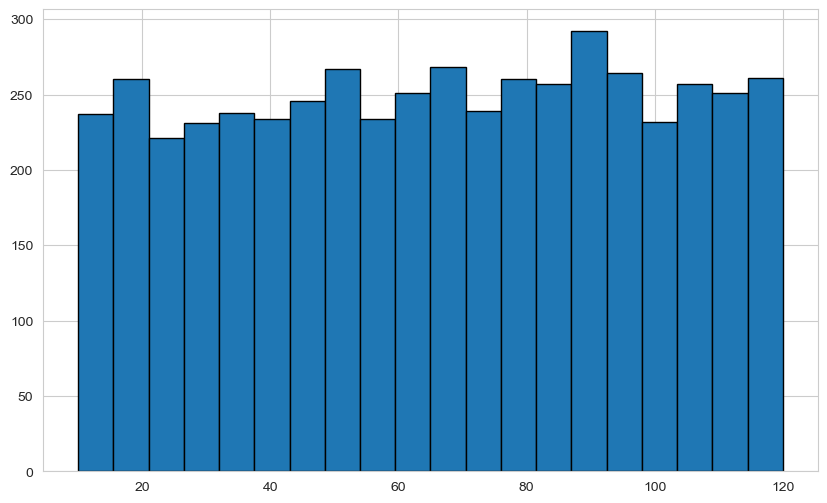

In [13]:
plt.hist(df_delivery['delivery_time_min'], bins = 20, edgecolor = 'black')

(array([251., 248., 257., 260., 252., 241., 247., 235., 276., 249., 251.,
        248., 226., 240., 212., 271., 239., 283., 248., 266.]),
 array([ 0.5  ,  1.475,  2.45 ,  3.425,  4.4  ,  5.375,  6.35 ,  7.325,
         8.3  ,  9.275, 10.25 , 11.225, 12.2  , 13.175, 14.15 , 15.125,
        16.1  , 17.075, 18.05 , 19.025, 20.   ]),
 <BarContainer object of 20 artists>)

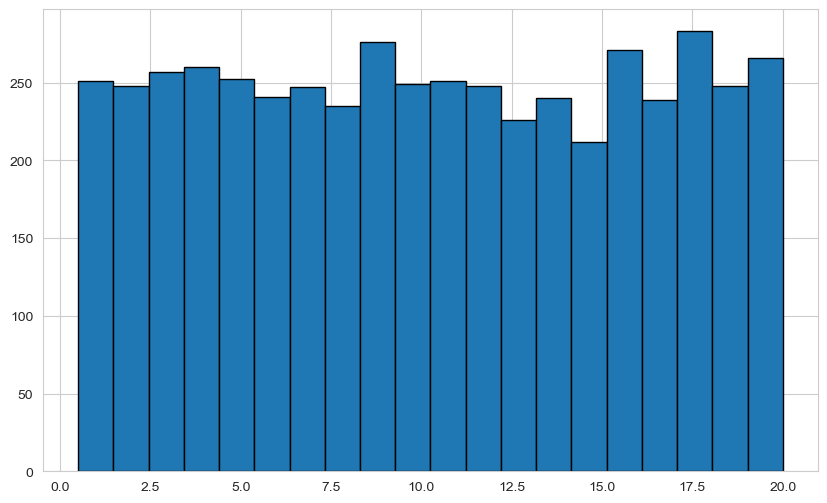

In [14]:
plt.hist(df_delivery['distance_km'], bins = 20, edgecolor = 'black')

<Axes: xlabel='city', ylabel='count'>

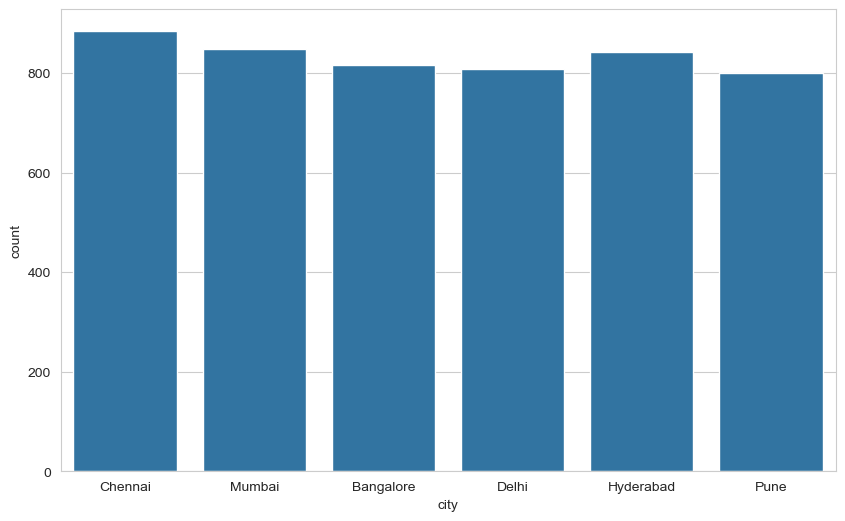

In [15]:
sns.countplot(x='city', data = df_delivery)

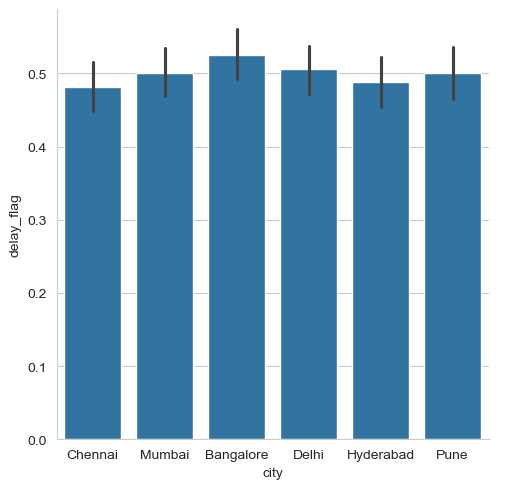

In [18]:
sns.catplot(x='city', y='delay_flag', data = df_delivery, kind = 'bar')